In [1]:
#load and explore

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_csv('/content/sample_data/telecom_churn.csv')

# Basic exploration
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nSummary statistics:\n", df.describe())

Shape: (1000, 12)

Data types:
 customer_id             object
age                      int64
region                  object
contract_type           object
plan                    object
monthly_charge_eur     float64
tenure_months            int64
avg_calls_per_month      int64
avg_data_gb            float64
support_calls            int64
late_payments            int64
churned                  int64
dtype: object

First 5 rows:
   customer_id  age         region contract_type   plan  monthly_charge_eur  \
0   CUST-0001   56        Utrecht        2-Year  Basic               34.52   
1   CUST-0002   69        Utrecht       Monthly  Basic               21.00   
2   CUST-0003   46  Noord-Holland       Monthly  Basic               29.72   
3   CUST-0004   32     Gelderland       Monthly  Basic               21.11   
4   CUST-0005   60  Noord-Brabant        1-Year  Basic               25.63   

   tenure_months  avg_calls_per_month  avg_data_gb  support_calls  \
0             25            

In [2]:
#Data quality check

# Missing values
print("Missing values:\n", df.isnull().sum())

# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Unique values in categorical columns
print("\nContract types:", df['contract_type'].value_counts())
print("\nRegions:", df['region'].value_counts())
print("\nPlans:", df['plan'].value_counts())

# Churn distribution
print("\nChurn distribution:\n", df['churned'].value_counts())
print("Overall churn rate:", round(df['churned'].mean() * 100, 1), "%")

Missing values:
 customer_id            0
age                    0
region                 0
contract_type          0
plan                   0
monthly_charge_eur     0
tenure_months          0
avg_calls_per_month    0
avg_data_gb            0
support_calls          0
late_payments          0
churned                0
dtype: int64

Duplicate rows: 0

Contract types: contract_type
Monthly    484
1-Year     315
2-Year     201
Name: count, dtype: int64

Regions: region
Noord-Holland    176
Overijssel       172
Utrecht          170
Gelderland       169
Zuid-Holland     163
Noord-Brabant    150
Name: count, dtype: int64

Plans: plan
Standard    397
Basic       307
Premium     296
Name: count, dtype: int64

Churn distribution:
 churned
0    623
1    377
Name: count, dtype: int64
Overall churn rate: 37.7 %


/tmp/ipykernel_3855/2315095980.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['tenure_months'],


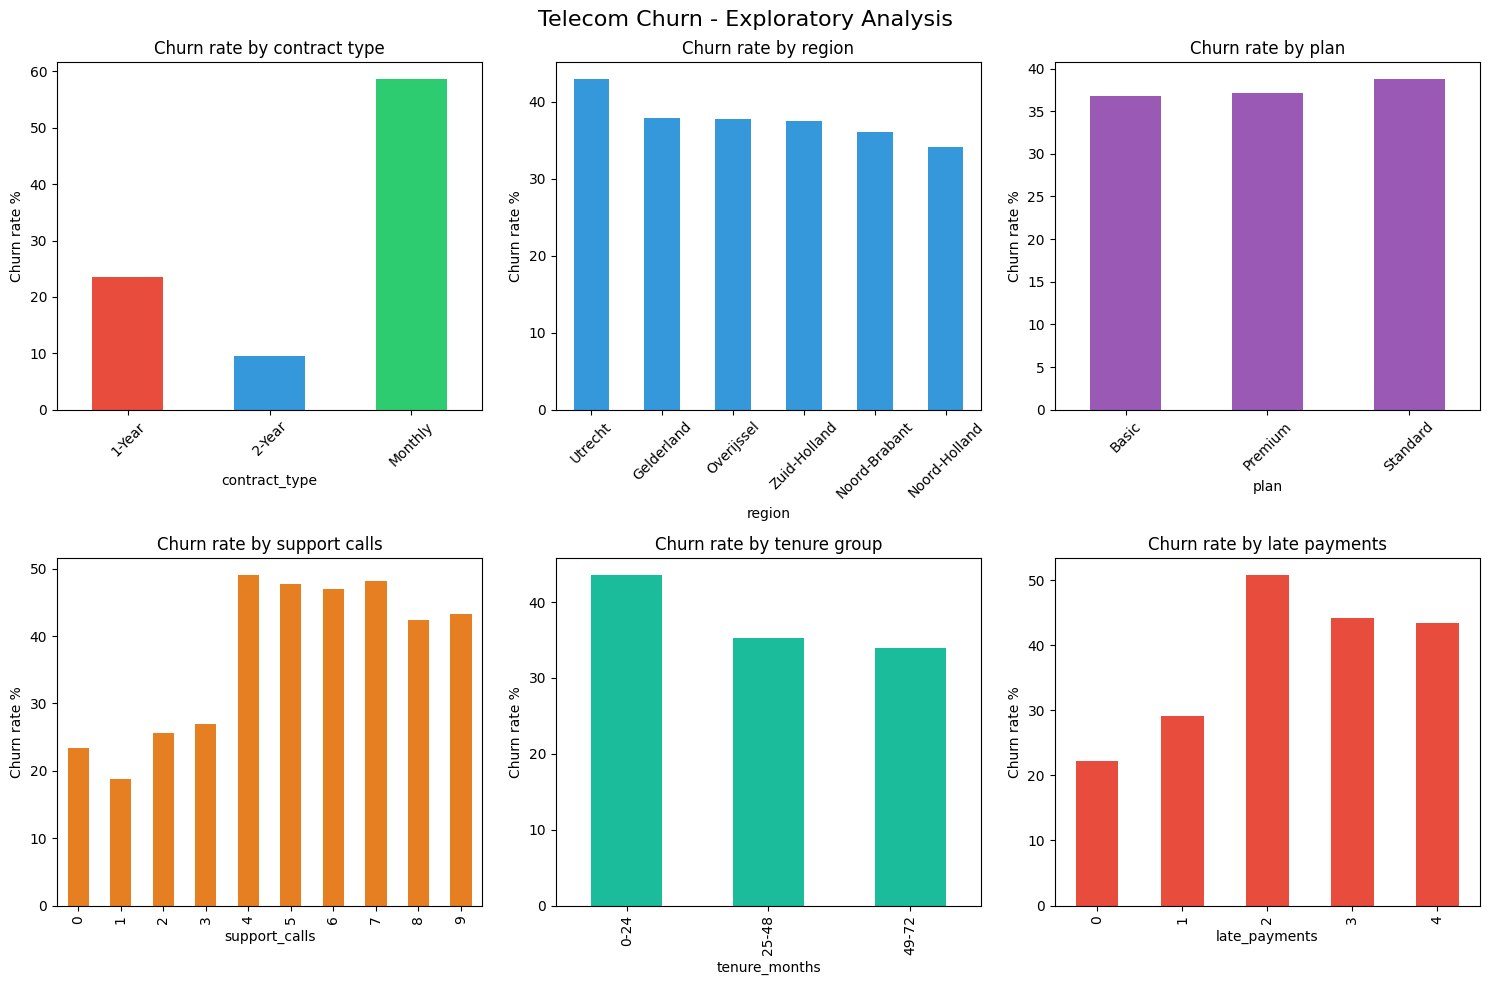

In [3]:
#Exploratory visualisations

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Telecom Churn - Exploratory Analysis', fontsize=16)

# Churn by contract type
df.groupby('contract_type')['churned'].mean().mul(100).plot(
    kind='bar', ax=axes[0,0], color=['#e74c3c', '#3498db', '#2ecc71']
)
axes[0,0].set_title('Churn rate by contract type')
axes[0,0].set_ylabel('Churn rate %')
axes[0,0].tick_params(axis='x', rotation=45)

# Churn by region
df.groupby('region')['churned'].mean().mul(100).sort_values(
    ascending=False
).plot(kind='bar', ax=axes[0,1], color='#3498db')
axes[0,1].set_title('Churn rate by region')
axes[0,1].set_ylabel('Churn rate %')
axes[0,1].tick_params(axis='x', rotation=45)

# Churn by plan
df.groupby('plan')['churned'].mean().mul(100).plot(
    kind='bar', ax=axes[0,2], color='#9b59b6'
)
axes[0,2].set_title('Churn rate by plan')
axes[0,2].set_ylabel('Churn rate %')
axes[0,2].tick_params(axis='x', rotation=45)

# Support calls vs churn
df.groupby('support_calls')['churned'].mean().mul(100).plot(
    kind='bar', ax=axes[1,0], color='#e67e22'
)
axes[1,0].set_title('Churn rate by support calls')
axes[1,0].set_ylabel('Churn rate %')

# Tenure vs churn
df.groupby(pd.cut(df['tenure_months'],
    bins=[0, 24, 48, 72],
    labels=['0-24', '25-48', '49-72'])
)['churned'].mean().mul(100).plot(
    kind='bar', ax=axes[1,1], color='#1abc9c'
)
axes[1,1].set_title('Churn rate by tenure group')
axes[1,1].set_ylabel('Churn rate %')

# Late payments vs churn
df.groupby('late_payments')['churned'].mean().mul(100).plot(
    kind='bar', ax=axes[1,2], color='#e74c3c'
)
axes[1,2].set_title('Churn rate by late payments')
axes[1,2].set_ylabel('Churn rate %')

plt.tight_layout()
plt.savefig('exploratory_analysis.png', dpi=150)
plt.show()

In [4]:
#tests

#T-tests
print("=" * 50)
print("T-TEST RESULTS")
print("=" * 50)

# Split into churned and not churned
churned = df[df['churned'] == 1]
not_churned = df[df['churned'] == 0]

# Test each numerical column
columns_to_test = [
    'support_calls',
    'late_payments',
    'monthly_charge_eur',
    'tenure_months',
    'avg_data_gb'
]

for col in columns_to_test:
    t_stat, p_value = stats.ttest_ind(
        churned[col],
        not_churned[col]
    )
    significance = "SIGNIFICANT" if p_value < 0.05 else "NOT significant"
    print(f"\n{col}:")
    print(f"  Churned avg:     {churned[col].mean():.2f}")
    print(f"  Not churned avg: {not_churned[col].mean():.2f}")
    print(f"  P-value:         {p_value:.4f}")
    print(f"  Result:          {significance}")

T-TEST RESULTS

support_calls:
  Churned avg:     5.18
  Not churned avg: 4.10
  P-value:         0.0000
  Result:          SIGNIFICANT

late_payments:
  Churned avg:     2.31
  Not churned avg: 1.81
  P-value:         0.0000
  Result:          SIGNIFICANT

monthly_charge_eur:
  Churned avg:     51.01
  Not churned avg: 51.20
  P-value:         0.8996
  Result:          NOT significant

tenure_months:
  Churned avg:     34.18
  Not churned avg: 37.66
  P-value:         0.0094
  Result:          SIGNIFICANT

avg_data_gb:
  Churned avg:     23.90
  Not churned avg: 24.61
  P-value:         0.4399
  Result:          NOT significant


In [5]:
#Chi-square test
print("=" * 50)
print("CHI-SQUARE TEST RESULTS")
print("=" * 50)

# Test each categorical column
categorical_columns = [
    'contract_type',
    'region',
    'plan'
]

for col in categorical_columns:
    contingency_table = pd.crosstab(df[col], df['churned'])
    chi2, p_value, dof, expected = stats.chi2_contingency(
        contingency_table
    )
    significance = "SIGNIFICANT" if p_value < 0.05 else "NOT significant"
    print(f"\n{col} vs churn:")
    print(f"  Chi-square: {chi2:.4f}")
    print(f"  P-value:    {p_value:.4f}")
    print(f"  Result:     {significance}")

CHI-SQUARE TEST RESULTS

contract_type vs churn:
  Chi-square: 186.0416
  P-value:    0.0000
  Result:     SIGNIFICANT

region vs churn:
  Chi-square: 3.1569
  P-value:    0.6758
  Result:     NOT significant

plan vs churn:
  Chi-square: 0.3417
  P-value:    0.8430
  Result:     NOT significant


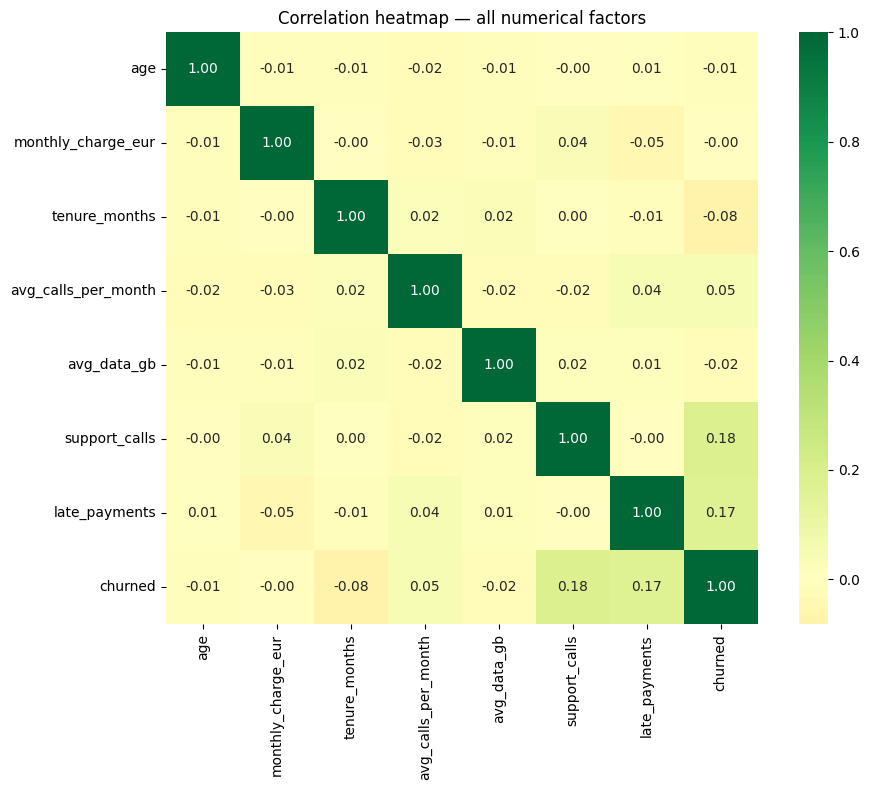


Correlations with churn (strongest first):
churned                1.000000
support_calls          0.183963
late_payments          0.170500
avg_calls_per_month    0.045183
monthly_charge_eur    -0.003994
age                   -0.013739
avg_data_gb           -0.024453
tenure_months         -0.082049
Name: churned, dtype: float64


In [6]:
#Correlation

# Select numerical columns
numerical_cols = [
    'age',
    'monthly_charge_eur',
    'tenure_months',
    'avg_calls_per_month',
    'avg_data_gb',
    'support_calls',
    'late_payments',
    'churned'
]

# Calculate correlation
correlation = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True
)
plt.title('Correlation heatmap — all numerical factors')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

# Print strongest correlations with churn
print("\nCorrelations with churn (strongest first):")
print(correlation['churned'].sort_values(ascending=False))

In [7]:
#Logistic regression
# Prepare data
df_model = df.copy()

# Encode categorical columns
le = LabelEncoder()
df_model['contract_type_encoded'] = le.fit_transform(
    df_model['contract_type']
)
df_model['region_encoded'] = le.fit_transform(
    df_model['region']
)
df_model['plan_encoded'] = le.fit_transform(
    df_model['plan']
)

# Define features and target
features = [
    'age',
    'monthly_charge_eur',
    'tenure_months',
    'avg_calls_per_month',
    'avg_data_gb',
    'support_calls',
    'late_payments',
    'contract_type_encoded',
    'region_encoded',
    'plan_encoded'
]

X = df_model[features]
y = df_model['churned']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print("\nClassification report:")
print(classification_report(y_test, y_pred))

LOGISTIC REGRESSION RESULTS

Classification report:
              precision    recall  f1-score   support

           0       0.77      0.80      0.79       128
           1       0.62      0.57      0.59        72

    accuracy                           0.72       200
   macro avg       0.69      0.69      0.69       200
weighted avg       0.72      0.72      0.72       200




Feature importance (strongest churn predictors):
                 feature  coefficient
7  contract_type_encoded     0.872320
6          late_payments     0.226550
5          support_calls     0.169491
8         region_encoded     0.041736
9           plan_encoded     0.020313
2          tenure_months     0.011104
0                    age     0.003419
4            avg_data_gb     0.002586
3    avg_calls_per_month     0.001745
1     monthly_charge_eur     0.001163


/tmp/ipykernel_3855/2736095839.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


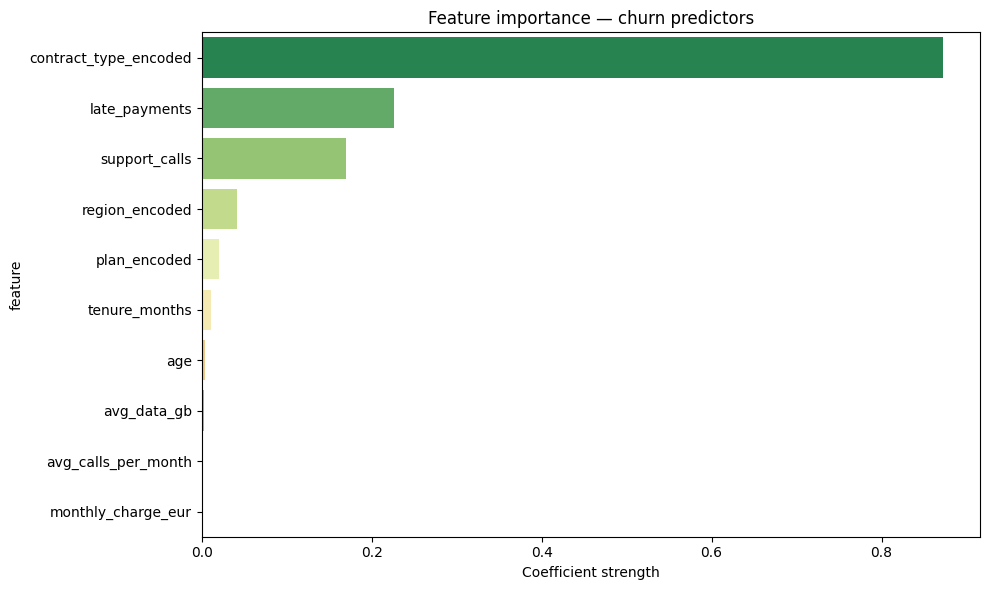

In [8]:
#Feature importance
# Get feature importance
importance = pd.DataFrame({
    'feature': features,
    'coefficient': abs(model.coef_[0])
}).sort_values('coefficient', ascending=False)

print("\nFeature importance (strongest churn predictors):")
print(importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance,
    x='coefficient',
    y='feature',
    palette='RdYlGn_r'
)
plt.title('Feature importance — churn predictors')
plt.xlabel('Coefficient strength')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()